In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# use seaborn plotting defaults
import seaborn as sns; sns.set()

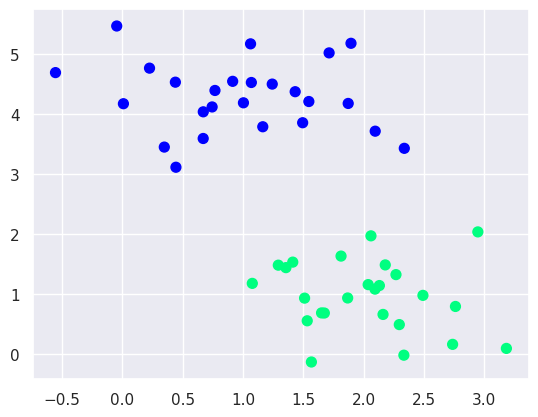

In [2]:

from sklearn.datasets import make_blobs   
X, y = make_blobs(n_samples=50, centers=2,
                  random_state=0, cluster_std=0.60)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')

In [3]:

from sklearn.svm import SVC # "Support vector classifier"
model = SVC(kernel='linear', C=1)
model.fit(X, y)

SVC(C=1, kernel='linear')

In [5]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)
    
    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

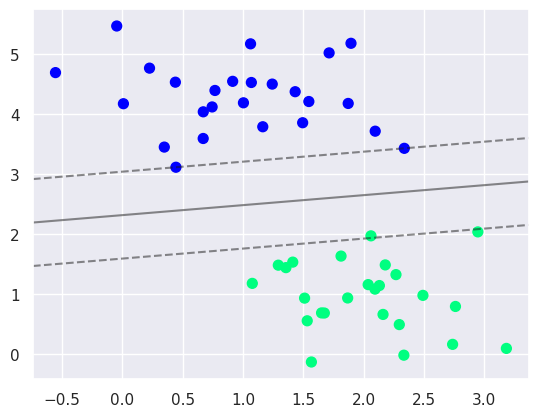

In [6]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
plot_svc_decision_function(model);

**no. of points dependency
aka support vector importance**

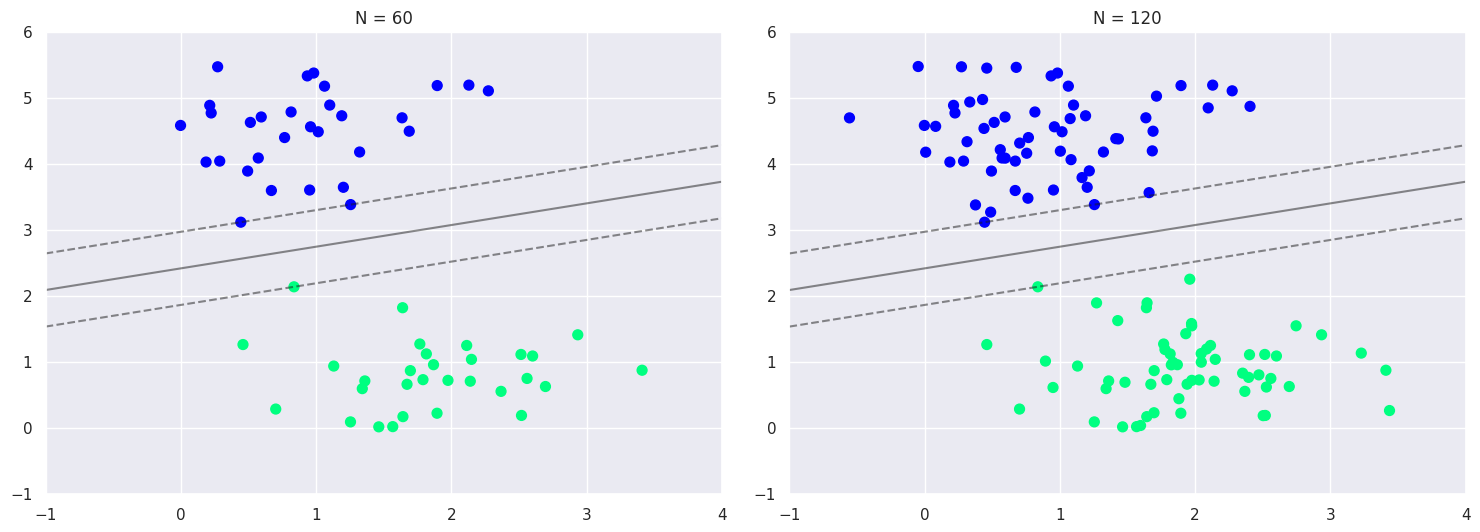

In [7]:
def plot_svm(N=10, ax=None):
    X, y = make_blobs(n_samples=200, centers=2,
                      random_state=0, cluster_std=0.60)
    X = X[:N]
    y = y[:N]
    model = SVC(kernel='linear', C=1E10)
    model.fit(X, y)
    
    ax = ax or plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)
    plot_svc_decision_function(model, ax)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)
for axi, N in zip(ax, [60, 120]):
    plot_svm(N, axi)
    axi.set_title('N = {0}'.format(N))


**NON LINEAR /ALMOST LINEAR DATA**

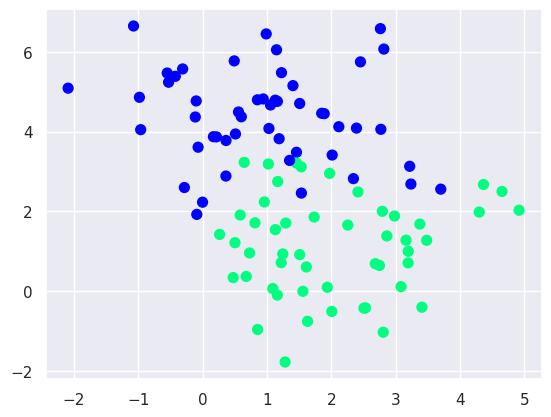

In [9]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=1.2)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter');

**C VALUE DEPENDENCY**

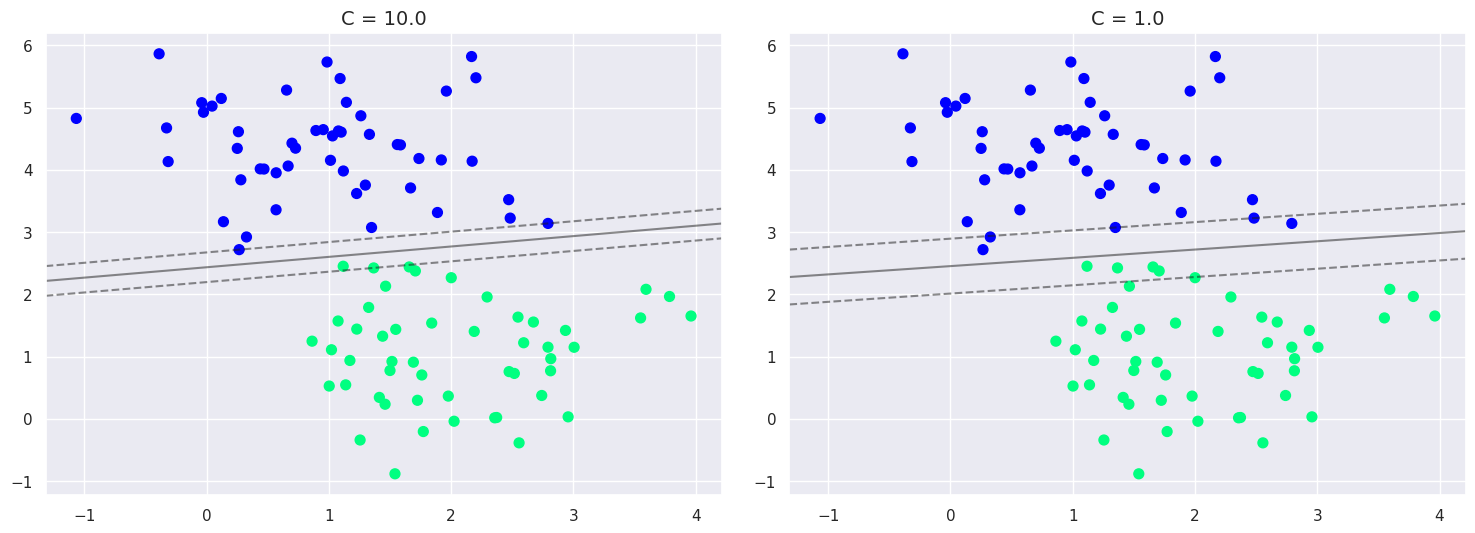

In [12]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=0.8)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

for axi, C in zip(ax, [10.0, 1]):
    model = SVC(kernel='linear', C=C).fit(X, y)
    axi.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
    plot_svc_decision_function(model, axi)
    axi.scatter(model.support_vectors_[:, 0],
                model.support_vectors_[:, 1],
                s=300, lw=1, facecolors='none');
    axi.set_title('C = {0:.1f}'.format(C), size=14)

In [20]:
class SVM_Visualizer:
    def __init__(self, learning_rate=0.01, C=1.0, epochs=1000):
        self.lr = learning_rate
        self.C = C
        self.epochs = epochs
        self.w = None
        self.b = None
        self.history = {} # Store weights and biases for visualization

    def fit(self, X, y, capture_epochs):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for epoch in range(1, self.epochs + 1):
            for idx, x_i in enumerate(X):
                condition = y[idx] * (np.dot(x_i, self.w) + self.b)
                
                if condition >= 1:
                    dw = self.w
                    db = 0
                else:
                    dw = self.w - self.C * y[idx] * x_i
                    db = -self.C * y[idx]
                    
                self.w -= self.lr * dw
                self.b -= self.lr * db
            
            # Capture the state at specific epochs
            if epoch in capture_epochs:
                self.history[epoch] = (self.w.copy(), self.b)

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def plot_final_svm(X, y, svm_model):
    plt.figure(figsize=(8, 6))
    
    # 1. Plot the data points
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k', s=50)
    
    # 2. Get the current plot boundaries
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # 3. Create the invisible grid (the "graph paper")
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    
    # 4. Plug every grid point into the SVM equation: w^T * x + b
    Z = (np.dot(xy, svm_model.w) + svm_model.b).reshape(XX.shape)
    
    # 5. Play "connect the dots" where the equation equals -1, 0, and 1
    ax.contour(XX, YY, Z, colors=['blue', 'black', 'red'], 
               levels=[-1, 0, 1], alpha=0.8,
               linestyles=['--', '-', '--'], linewidths=[2, 3, 2])
    
    # 6. Calculate and display the final Margin Distance (D)
    margin_dist = 2 / np.linalg.norm(svm_model.w)
    plt.title(f"Final SVM Decision Boundary | Maximum Margin D: {margin_dist:.2f}")
    
    plt.show()

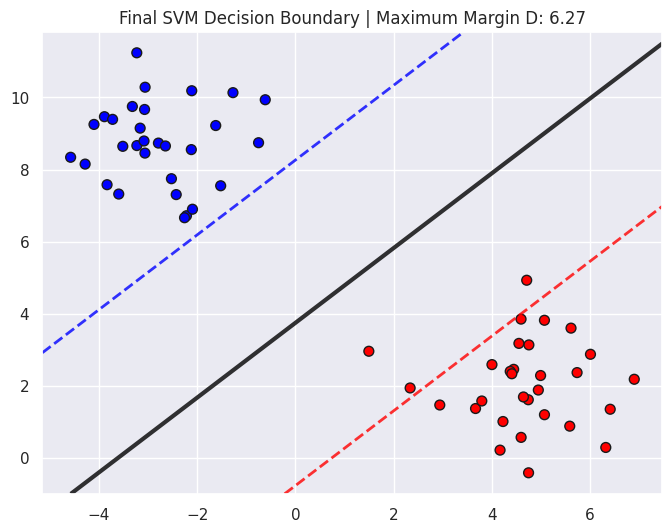

In [22]:
# Train the model (using the standard SVM class from earlier)
svm = SVM(learning_rate=0.01, C=1.0, n_iters=1000)
svm.fit(X, y)

# Render the single final plot
plot_final_svm(X, y, svm)